# Chapter IV — Side-Loaded Plate (Martins Comparison)

This notebook validates the `side_loaded_plate` implementation with the Martins-style setup:

- One inverse run with field logging (`comparison_Martins`)
- Plots saved to `images/` as PNG/PDF
- A 10-run batch without field logging in `results/side_loaded_plate/comparison_Martins_batch/`
- Batch summary table and convergence plots ($E$, $\nu$, and relative $L^2$ error)

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config, copy_config
import phd.models.cm.side_loaded_plate as slp
from phd.io import save_run_data as save_run_data_generic
from phd.io import load_run as load_run_generic

from phd.plot import get_current_config as plt_cfg, book_config, book_compact_config, A4_config, KUL_CYCLE

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = True
save_table = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")

PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "01_side_loaded_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
TABLE_DIR = CHAPTER_DIR / "tables"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ROOT = PROJECT_ROOT / "results" / "side_loaded_plate"
print(f"Project root: {PROJECT_ROOT}")
print(f"Results root: {RESULTS_ROOT}")

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



Project root: /home/r2d2/code/PhD
Results root: /home/r2d2/code/PhD/results/side_loaded_plate


In [2]:
def build_martins_cfg(seed: int = 0, save_fields: bool = True):
    cfg = load_config("side_loaded_plate")

    cfg.seed = seed
    cfg.task.type = "inverse"

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 3
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32

    cfg.problem.material.law = "isotropic"
    cfg.problem.geometry.length = 3.0
    cfg.problem.loading.m = 10.0
    cfg.problem.loading.b = 50.0

    # New config structure: dataset is selected from
    # problem.reference.dataset_by_length[material_law][geometry.length]
    assert int(cfg.problem.geometry.length) in cfg.problem.reference.dataset_by_length.isotropic, (
        f"No isotropic dataset mapping for length={cfg.problem.geometry.length}"
    )

    cfg.training.n_iter = 20000
    cfg.training.log_every = 250
    cfg.training.num_domain = 10000
    cfg.training.lr = 1e-3
    cfg.training.coord_normalization = False
    cfg.training.stress_bc = True
    cfg.training.self_attention.enabled = False
    cfg.training.loss_weights = [1.0] * 5 + [1e2] * 3
    cfg.training.loss_weight_grad_norm = True

    cfg.task.inverse.measurements.type = "strain"
    cfg.task.inverse.measurements.n_observations.x = 4
    cfg.task.inverse.measurements.n_observations.y = 4
    cfg.task.inverse.measurements.noise_ratio = 1e-6

    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.results.save_on_disk = False
    cfg.results.experiment_name = None

    if save_fields:
        cfg.problem.log_fields = ["Ux", "Uy", "Sxx", "Syy", "Sxy"]
    else:
        cfg.problem.log_fields = []

    return cfg

cfg_preview = build_martins_cfg(seed=0, save_fields=True)
print(f"Model: {cfg_preview.model.net_type} / {cfg_preview.model.formulation}")
print(f"Measurements: {cfg_preview.task.inverse.measurements.type}, {cfg_preview.task.inverse.measurements.n_observations.x}x{cfg_preview.task.inverse.measurements.n_observations.y}")
print(f"Noise ratio: {cfg_preview.task.inverse.measurements.noise_ratio}")
print(f"Geometry length: {cfg_preview.problem.geometry.length}")

Model: SPINN / mixed
Measurements: strain, 4x4
Noise ratio: 1e-06
Geometry length: 3.0


In [3]:
# 1) Single reference run with field logging
single_mode = "load"  # "run" or "load"
single_run_name = "comparison_Martins"

if single_mode == "run":
    cfg_single = build_martins_cfg(seed=0, save_fields=True)
    results_single = slp.train(cfg_single)
    single_run_dir = slp.save_run_data(results_single, run_name=single_run_name)
else:
    results_single = slp.load_run(single_run_name)
    single_run_dir = Path(results_single["run_dir"])

print(f"Single run [{single_mode}] at: {single_run_dir}")

W0216 18:13:56.440103 2245299 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0216 18:13:56.444005 2245131 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


Single run [load] at: /home/r2d2/code/PhD/results/side_loaded_plate/comparison_Martins


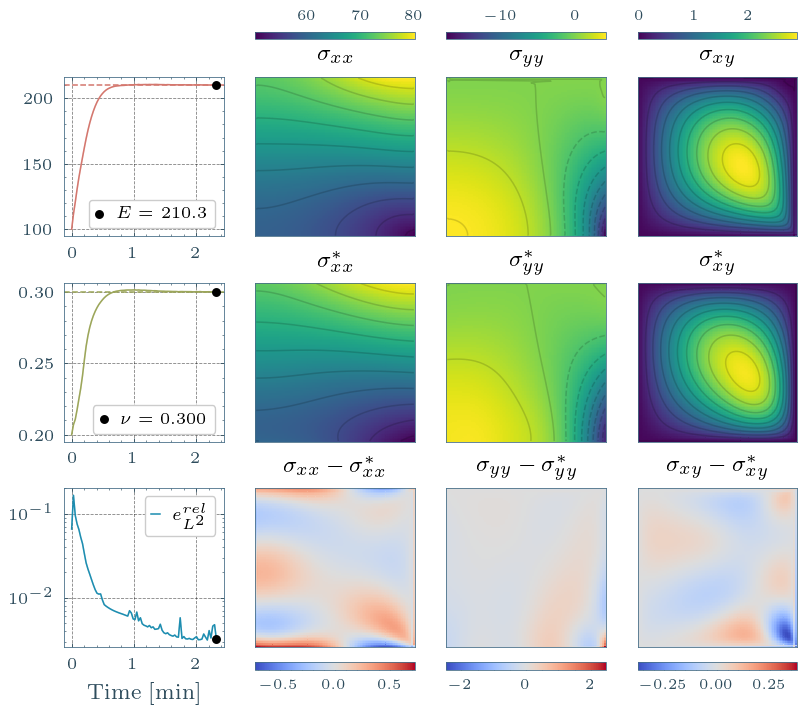

Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/comparison_Martins_results.png
Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/pdf/comparison_Martins_results.pdf


In [4]:
# Plot and save the single-run results (analytical-plate style)
fig, artists = slp.plot_results(
    results_single,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Sxx", "Syy", "Sxy"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
)
plt.show()

if save_fig:
    figure_name = "comparison_Martins_results"
    fig.savefig(IMAGE_DIR / f"{figure_name}.png", bbox_inches="tight", dpi=300)
    fig.savefig(PDF_DIR / f"{figure_name}.pdf", bbox_inches="tight")
    print(f"Saved: {IMAGE_DIR / (figure_name + '.png')}")
    print(f"Saved: {PDF_DIR / (figure_name + '.pdf')}")

In [ ]:
# 2) Batch of 10 runs (no field logging), saved in results/side_loaded_plate/comparison_Martins_batch
batch_mode = "load"  # "run" or "load"
n_batch_runs = 10
batch_problem = "side_loaded_plate/comparison_Martins_batch"
batch_root = RESULTS_ROOT / "comparison_Martins_batch"
batch_run_dirs = []

if batch_mode == "run":
    for run_idx in range(n_batch_runs):
        cfg_batch = build_martins_cfg(seed=run_idx, save_fields=False)
        batch_results = slp.train(cfg_batch)
        run_dir = save_run_data_generic(batch_results, problem=batch_problem)
        batch_run_dirs.append(Path(run_dir))
        print(f"Run {run_idx + 1:02d}/{n_batch_runs}: {run_dir}")
else:
    if not batch_root.exists():
        raise FileNotFoundError(f"Batch folder not found: {batch_root}")

    available_run_dirs = sorted([p for p in batch_root.iterdir() if p.is_dir()])
    if len(available_run_dirs) < n_batch_runs:
        raise ValueError(
            f"Requested {n_batch_runs} runs but found only {len(available_run_dirs)} in {batch_root}."
        )

    # Use the latest n runs
    selected_dirs = available_run_dirs[-n_batch_runs:]
    for run_dir in selected_dirs:
        loaded = load_run_generic(run_name=run_dir.name, problem=batch_problem, base_dir=PROJECT_ROOT / "results")
        batch_run_dirs.append(Path(loaded["run_dir"]))
        print(f"Loaded: {run_dir.name}")

print(f"Batch mode: {batch_mode}")
print(f"Batch folder: {batch_root}")
print(f"Runs used: {len(batch_run_dirs)}")

In [ ]:
def load_history(run_dir: Path):
    loss_hist = np.loadtxt(run_dir / "loss_history.dat")
    var_hist = np.loadtxt(run_dir / "variables.dat")

    if loss_hist.ndim == 1:
        loss_hist = loss_hist.reshape(1, -1)
    if var_hist.ndim == 1:
        var_hist = var_hist.reshape(1, -1)

    steps = loss_hist[:, 0]
    losses = loss_hist[:, 1:]

    l2_err = losses[:, -1]
    pde_loss = losses[:, 0:2].mean(axis=1)
    mat_loss = losses[:, 2:5].mean(axis=1) if losses.shape[1] >= 5 else np.full_like(l2_err, np.nan)
    dic_loss = losses[:, 5:8].mean(axis=1) if losses.shape[1] >= 8 else np.full_like(l2_err, np.nan)

    E_hist = var_hist[:, 1]
    nu_hist = var_hist[:, 2]

    return {
        "steps": steps,
        "l2": l2_err,
        "pde": pde_loss,
        "mat": mat_loss,
        "dic": dic_loss,
        "E": E_hist,
        "nu": nu_hist,
    }

histories = [load_history(Path(d)) for d in batch_run_dirs]
n_common = min(len(h["steps"]) for h in histories)

steps = histories[0]["steps"][:n_common]
l2_all = np.vstack([h["l2"][:n_common] for h in histories])
pde_all = np.vstack([h["pde"][:n_common] for h in histories])
mat_all = np.vstack([h["mat"][:n_common] for h in histories])
dic_all = np.vstack([h["dic"][:n_common] for h in histories])
E_all = np.vstack([h["E"][:n_common] for h in histories])
nu_all = np.vstack([h["nu"][:n_common] for h in histories])

with open(batch_run_dirs[0] / "run_data.json", "r") as f:
    batch_run_data = json.load(f)

cfg_batch_loaded = batch_run_data["config"]
E_ref = cfg_batch_loaded["problem"]["material"]["isotropic"]["E"] / 1e3
nu_ref = cfg_batch_loaded["problem"]["material"]["isotropic"]["nu"]
E_init = cfg_batch_loaded["task"]["inverse"]["init_guess"]["isotropic"]["E"] / 1e3
nu_init = cfg_batch_loaded["task"]["inverse"]["init_guess"]["isotropic"]["nu"]

print(f"Loaded {len(histories)} runs with {n_common} common steps.")

In [ ]:
# Batch summary table (as in legacy multi-run workflow)
E_finals = E_all[:, -10:].mean(axis=1) / 1e3
nu_finals = nu_all[:, -10:].mean(axis=1)
l2_finals = l2_all[:, -1]

summary_rows = [
    {
        "Parameter": "E [GPa]",
        "Initial": E_init,
        "Final mean": E_finals.mean(),
        "Final std": E_finals.std(),
        "Final min": E_finals.min(),
        "Final max": E_finals.max(),
        "Reference": E_ref,
        "Max Rel. Error [%]": np.max(np.abs(E_finals - E_ref) / E_ref) * 100,
    },
    {
        "Parameter": r"nu",
        "Initial": nu_init,
        "Final mean": nu_finals.mean(),
        "Final std": nu_finals.std(),
        "Final min": nu_finals.min(),
        "Final max": nu_finals.max(),
        "Reference": nu_ref,
        "Max Rel. Error [%]": np.max(np.abs(nu_finals - nu_ref) / nu_ref) * 100,
    },
]

df_summary = pd.DataFrame(summary_rows)
numeric_cols = [
    "Initial",
    "Final mean",
    "Final std",
    "Final min",
    "Final max",
    "Reference",
    "Max Rel. Error [%]",
]

df_summary_display = df_summary.copy()
e_mask = df_summary_display["Parameter"] == "E [GPa]"
for col in numeric_cols:
    df_summary_display.loc[e_mask, col] = df_summary_display.loc[e_mask, col].map(lambda v: f"{v:.1f}")
    df_summary_display.loc[~e_mask, col] = df_summary_display.loc[~e_mask, col].map(lambda v: f"{v:.4f}")
display(df_summary_display)

if save_table:
    table_path = TABLE_DIR / "comparison_Martins_batch_summary.tex"
    df_summary_display.to_latex(table_path, index=False)
    print(f"Saved: {table_path}")

print(f"Final L2 mean ± std: {l2_finals.mean():.3e} ± {l2_finals.std():.3e}")

In [ ]:
# Convergence plot: parameters + relative L2 error (mean ± std)
fig, axes = plt.subplots(1, 3, figsize=(10, 3), dpi=200)

COLOR_L2 = KUL_CYCLE[2]  # Olive/green
COLOR_E = KUL_CYCLE[0]   # Primary blue
COLOR_NU = KUL_CYCLE[1]  # Coral

def plot_mean_std(ax, x, y_all, label, color, logy=False):
    y_mean = y_all.mean(axis=0)
    y_std = y_all.std(axis=0)
    y_low = np.maximum(y_mean - y_std, 1e-16) if logy else (y_mean - y_std)
    y_high = y_mean + y_std
    ax.plot(x, y_mean, color=color, label=label)
    ax.fill_between(x, y_low, y_high, color=color, alpha=0.25)
    if logy:
        ax.set_yscale("log")

plot_mean_std(axes[0], steps, l2_all, r"$L^2$ error", COLOR_L2, logy=True)
axes[0].set_title(r"Relative $L^2$ Error")
axes[0].set_xlabel("Iterations")
axes[0].legend()

plot_mean_std(axes[1], steps, E_all / 1e3, r"$E$", COLOR_E)
axes[1].axhline(E_ref, color=COLOR_E, linestyle="--", alpha=0.8, label="Reference")
axes[1].set_title(r"$E$ [GPa]")
axes[1].set_xlabel("Iterations")
axes[1].legend()

plot_mean_std(axes[2], steps, nu_all, r"$nu$", COLOR_NU)
axes[2].axhline(nu_ref, color=COLOR_NU, linestyle="--", alpha=0.8, label="Reference")
axes[2].set_title(r"$nu$")
axes[2].set_xlabel("Iterations")
axes[2].legend()

plt.tight_layout()
plt.show()

if save_fig:
    figure_name = "comparison_Martins_batch_convergence"
    fig.savefig(IMAGE_DIR / f"{figure_name}.png", bbox_inches="tight", dpi=300)
    fig.savefig(PDF_DIR / f"{figure_name}.pdf", bbox_inches="tight")
    print(f"Saved: {IMAGE_DIR / (figure_name + '.png')}")
    print(f"Saved: {PDF_DIR / (figure_name + '.pdf')}")